# EDA — Lamé Sphere Dataset

Exploratory analysis of the 5 000-case thick-walled hollow sphere dataset.
Physics: Lamé (1852) analytical solution for a sphere under combined internal/external pressure.

**Geometry:** inner radius $a = 0.2$ m, outer radius $b = 0.5$ m.  
**Parameters per case:** $(p_i, p_e, E, \nu)$  
**Target fields at 409 230 FEM mesh vertices:** $\sigma_\text{vm}$, $u_r$, $\sigma_r$, $\sigma_\theta$

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from scipy import stats
from pathlib import Path

from neural_operators.data.lame_sphere import (
    A, B, N_PTS, QUERY_XYZ,
    PI_RANGE, PE_RANGE, E_RANGE, NU_RANGE,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

DATA_DIR = Path("../dataset")
RNG = np.random.default_rng(0)

print(f"N_PTS = {N_PTS:,}   |   inner radius a = {A} m   |   outer radius b = {B} m")

N_PTS = 409,230   |   inner radius a = 0.2 m   |   outer radius b = 0.5 m


## 1 — Load scalar parameters

In [2]:
SCALAR_COLS = ["case_id", "p_i", "p_e", "E", "nu"]

splits = {}
for split in ("train", "val", "test"):
    path = DATA_DIR / f"lame_sphere_{split}.parquet"
    t = pq.read_table(path, columns=SCALAR_COLS)
    df = t.to_pandas()
    df["split"] = split
    splits[split] = df
    meta = t.schema.metadata or {}
    print(f"{split:5s}: {len(df):>5} cases  |  "
          f"N_PTS={meta.get(b'N_PTS', b'?').decode()}  "
          f"inner_r={meta.get(b'inner_radius', b'?').decode()} m  "
          f"outer_r={meta.get(b'outer_radius', b'?').decode()} m")

all_df = pd.concat(splits.values(), ignore_index=True)
all_df["delta_p"] = all_df["p_i"] - all_df["p_e"]
print(f"\nTotal: {len(all_df):,} cases")

train:  3500 cases  |  N_PTS=?  inner_r=? m  outer_r=? m
val  :   750 cases  |  N_PTS=?  inner_r=? m  outer_r=? m
test :   750 cases  |  N_PTS=?  inner_r=? m  outer_r=? m

Total: 5,000 cases


## 2 — Summary statistics

In [3]:
cols = {"p_i [MPa]": all_df["p_i"] / 1e6,
        "p_e [MPa]": all_df["p_e"] / 1e6,
        "delta_p [MPa]": all_df["delta_p"] / 1e6,
        "E [GPa]": all_df["E"] / 1e9,
        "nu [-]": all_df["nu"]}

rows = []
for name, s in cols.items():
    rows.append({
        "param": name,
        "min": s.min(), "P5": s.quantile(0.05),
        "mean": s.mean(), "std": s.std(),
        "P50": s.median(), "P95": s.quantile(0.95),
        "max": s.max(),
    })

stats_df = pd.DataFrame(rows).set_index("param")
pd.options.display.float_format = "{:.3f}".format
display(stats_df)

,min,P5,mean,std,P50,P95,max
param,,,,,,,
p_i [MPa],1.010,1.968,10.417,5.482,10.348,19.028,19.996
p_e [MPa],0.001,0.191,2.272,1.432,2.138,4.687,5.000
delta_p [MPa],0.100,0.640,8.145,5.318,7.950,16.974,19.868
E [GPa],50.001,54.576,124.369,56.084,112.737,229.924,249.979
nu [-],0.200,0.212,0.326,0.073,0.327,0.438,0.450


## 3 — Parameter distributions

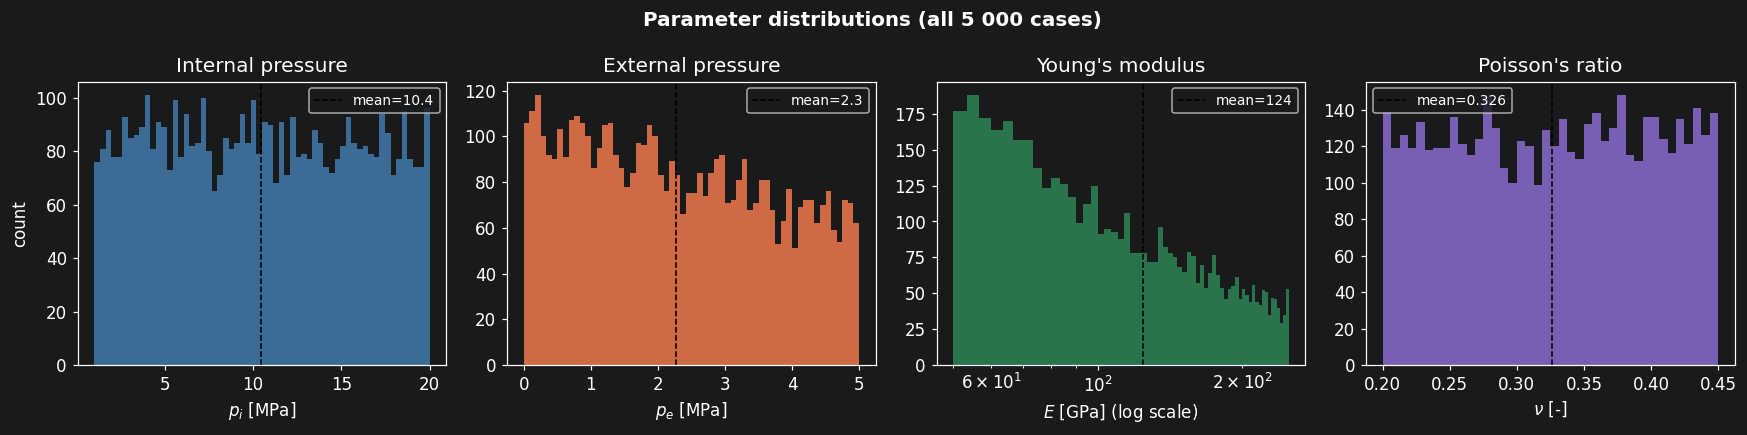

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Parameter distributions (all 5 000 cases)", fontsize=13, fontweight="bold")

pi_mpa = all_df["p_i"] / 1e6
pe_mpa = all_df["p_e"] / 1e6
E_gpa  = all_df["E"] / 1e9

axes[0].hist(pi_mpa, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set(xlabel="$p_i$ [MPa]", ylabel="count", title="Internal pressure")
axes[0].axvline(pi_mpa.mean(), color="k", ls="--", lw=1, label=f"mean={pi_mpa.mean():.1f}")
axes[0].legend(fontsize=9)

axes[1].hist(pe_mpa, bins=60, color="coral", edgecolor="none", alpha=0.8)
axes[1].set(xlabel="$p_e$ [MPa]", title="External pressure")
axes[1].axvline(pe_mpa.mean(), color="k", ls="--", lw=1, label=f"mean={pe_mpa.mean():.1f}")
axes[1].legend(fontsize=9)

axes[2].hist(E_gpa, bins=60, color="seagreen", edgecolor="none", alpha=0.8)
axes[2].set(xlabel="$E$ [GPa] (log scale)", title="Young's modulus", xscale="log")
axes[2].axvline(E_gpa.mean(), color="k", ls="--", lw=1, label=f"mean={E_gpa.mean():.0f}")
axes[2].legend(fontsize=9)

axes[3].hist(all_df["nu"], bins=40, color="mediumpurple", edgecolor="none", alpha=0.8)
axes[3].set(xlabel="$\\nu$ [-]", title="Poisson's ratio")
axes[3].axvline(all_df["nu"].mean(), color="k", ls="--", lw=1,
                label=f"mean={all_df['nu'].mean():.3f}")
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4 — Sampling constraints

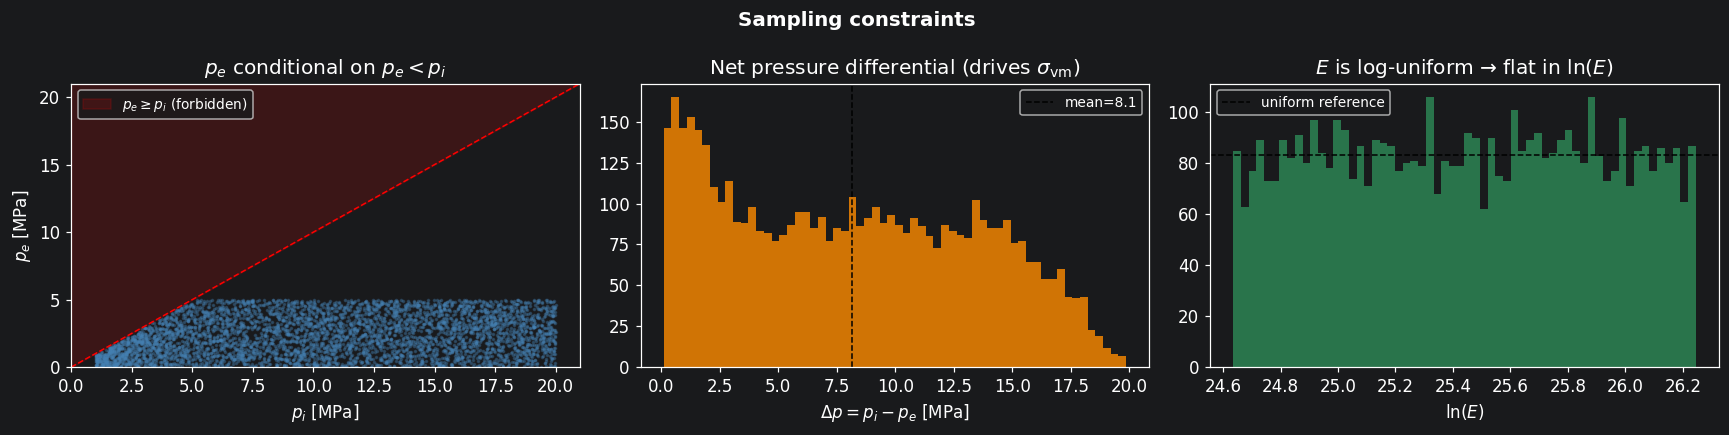

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Sampling constraints", fontsize=13, fontweight="bold")

# p_e vs p_i scatter with forbidden region
ax = axes[0]
ax.scatter(pi_mpa, pe_mpa, s=2, alpha=0.3, color="steelblue")
lim = float(pi_mpa.max()) * 1.05
ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.15, color="red",
                label="$p_e \\geq p_i$ (forbidden)")
ax.plot([0, lim], [0, lim], "r--", lw=1)
ax.set(xlabel="$p_i$ [MPa]", ylabel="$p_e$ [MPa]",
       title="$p_e$ conditional on $p_e < p_i$", xlim=(0, lim), ylim=(0, lim))
ax.legend(fontsize=9)

# delta_p histogram
dp_mpa = all_df["delta_p"] / 1e6
axes[1].hist(dp_mpa, bins=60, color="darkorange", edgecolor="none", alpha=0.8)
axes[1].set(xlabel="$\\Delta p = p_i - p_e$ [MPa]",
            title="Net pressure differential (drives $\\sigma_\\mathrm{vm}$)")
axes[1].axvline(dp_mpa.mean(), color="k", ls="--", lw=1, label=f"mean={dp_mpa.mean():.1f}")
axes[1].legend(fontsize=9)

# log(E) should be uniform
log_E = np.log(all_df["E"])
axes[2].hist(log_E, bins=60, color="seagreen", edgecolor="none", alpha=0.8)
axes[2].set(xlabel="$\\ln(E)$", title="$E$ is log-uniform → flat in $\\ln(E)$")
# overlay uniform reference
lo, hi = log_E.min(), log_E.max()
axes[2].axhline(len(log_E) / 60, color="k", ls="--", lw=1, label="uniform reference")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5 — Mesh geometry

In [6]:
QR = np.linalg.norm(QUERY_XYZ, axis=1)  # (N_PTS,) float64 radial distances

inner_mask = QR < (A + 0.005)
outer_mask = QR > (B - 0.005)
shell_mask = ~inner_mask & ~outer_mask

print(f"Mesh composition  (N_PTS = {N_PTS:,}):")
print(f"  Inner surface  r < {A+0.005:.3f} m : {inner_mask.sum():>7,}  ({100*inner_mask.mean():.1f}%)")
print(f"  Shell interior               : {shell_mask.sum():>7,}  ({100*shell_mask.mean():.1f}%)")
print(f"  Outer surface  r > {B-0.005:.3f} m : {outer_mask.sum():>7,}  ({100*outer_mask.mean():.1f}%)")
print()
print("Note: outer surface is ~6× denser than inner. Training uses random subsampling")
print("(laptop.n_query_pts=4096) to avoid bias toward over-represented outer region.")

Mesh composition  (N_PTS = 409,230):
  Inner surface  r < 0.205 m :   6,926  (1.7%)
  Shell interior               : 359,686  (87.9%)
  Outer surface  r > 0.495 m :  42,618  (10.4%)

Note: outer surface is ~6× denser than inner. Training uses random subsampling
(laptop.n_query_pts=4096) to avoid bias toward over-represented outer region.


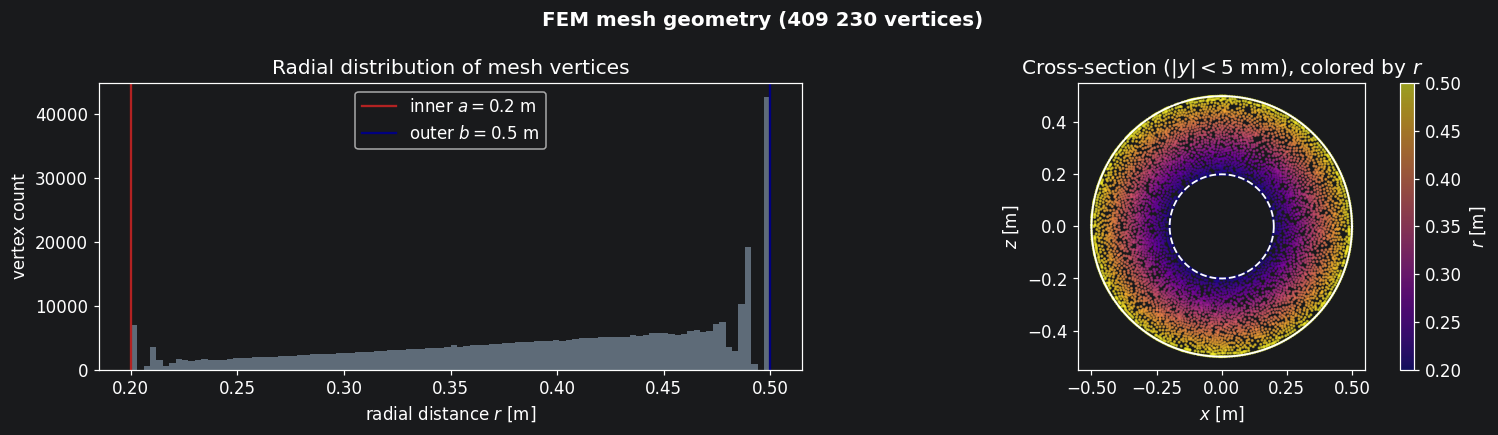

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("FEM mesh geometry (409 230 vertices)", fontsize=13, fontweight="bold")

# Radial distribution
axes[0].hist(QR, bins=100, color="slategray", edgecolor="none", alpha=0.8)
axes[0].axvline(A, color="firebrick", lw=1.5, label=f"inner $a={A}$ m")
axes[0].axvline(B, color="navy", lw=1.5, label=f"outer $b={B}$ m")
axes[0].set(xlabel="radial distance $r$ [m]", ylabel="vertex count",
            title="Radial distribution of mesh vertices")
axes[0].legend()

# Cross-section scatter: project to (x,z) at |y| < 5 mm
mid_mask = np.abs(QUERY_XYZ[:, 1]) < 0.005
x_cs = QUERY_XYZ[mid_mask, 0]
z_cs = QUERY_XYZ[mid_mask, 2]
r_cs = QR[mid_mask]
sc = axes[1].scatter(x_cs, z_cs, c=r_cs, cmap="plasma", s=1, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label="$r$ [m]")
theta = np.linspace(0, 2 * np.pi, 300)
for rad, ls in [(A, "--"), (B, "-")]:
    axes[1].plot(rad * np.cos(theta), rad * np.sin(theta), "w", lw=1.2, ls=ls)
axes[1].set(xlabel="$x$ [m]", ylabel="$z$ [m]",
            title="Cross-section ($|y| < 5$ mm), colored by $r$", aspect="equal")

plt.tight_layout()
plt.show()

## 6 — Load field sample (memory-safe)

In [8]:
N_SAMPLE = 200
N_Q = 4096        # match laptop.n_query_pts from lame_sphere.yaml
FIELD_COLS = ["case_id", "p_i", "p_e", "E", "nu",
              "sigma_vm", "u_r", "sigma_r", "sigma_theta"]

# Fixed random index subset of mesh points
query_idx = RNG.choice(N_PTS, size=N_Q, replace=False)
query_r = QR[query_idx]   # radial distance for the subsampled points

# Stream first N_SAMPLE rows from train parquet
pf = pq.ParquetFile(DATA_DIR / "lame_sphere_train.parquet")
rows = []
collected = 0
for batch in pf.iter_batches(batch_size=50, columns=FIELD_COLS):
    rows.append(batch.to_pandas())
    collected += len(batch)
    if collected >= N_SAMPLE:
        break
sample_df = pd.concat(rows, ignore_index=True).iloc[:N_SAMPLE]

# Extract subsampled field arrays
def _sub(col):
    return np.stack([np.asarray(v, dtype=np.float32)[query_idx]
                     for v in sample_df[col]], axis=0)  # (N_SAMPLE, N_Q)

sigma_vm_s = _sub("sigma_vm")
u_r_s      = _sub("u_r")
sigma_r_s  = _sub("sigma_r")
sigma_t_s  = _sub("sigma_theta")
params_s   = sample_df[["p_i", "p_e", "E", "nu"]].to_numpy(dtype=np.float32)

print(f"Loaded {N_SAMPLE} cases × {N_Q} query points")
print(f"sigma_vm range: [{sigma_vm_s.min()/1e6:.2f}, {sigma_vm_s.max()/1e6:.2f}] MPa")
print(f"u_r range:      [{u_r_s.min()*1e3:.3f}, {u_r_s.max()*1e3:.3f}] mm")

Loaded 200 cases × 4096 query points
sigma_vm range: [0.02, 31.78] MPa
u_r range:      [-0.014, 0.045] mm


## 7 — Field value distributions

Von Mises stress           skewness=+0.18
Radial displacement        skewness=+0.31
Radial stress              skewness=-0.22
Hoop stress                skewness=-0.09


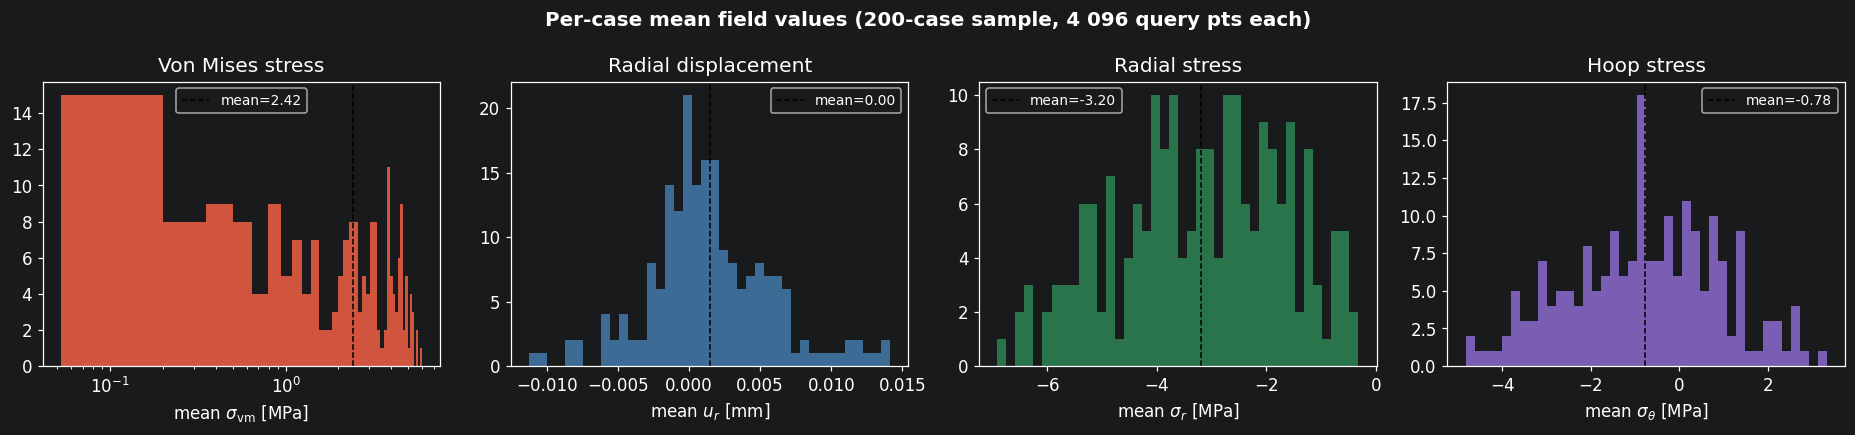

In [9]:
# Per-case mean of each field over the N_Q query points
mean_svm = sigma_vm_s.mean(axis=1) / 1e6   # MPa
mean_ur  = u_r_s.mean(axis=1) * 1e3        # mm
mean_sr  = sigma_r_s.mean(axis=1) / 1e6    # MPa
mean_st  = sigma_t_s.mean(axis=1) / 1e6    # MPa

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle("Per-case mean field values (200-case sample, 4 096 query pts each)",
             fontsize=13, fontweight="bold")

def _field_hist(ax, values, xlabel, title, color, log_x=False):
    ax.hist(values, bins=40, color=color, edgecolor="none", alpha=0.8)
    ax.set(xlabel=xlabel, title=title)
    if log_x:
        ax.set_xscale("log")
    mu, sg = values.mean(), values.std()
    ax.axvline(mu, color="k", ls="--", lw=1, label=f"mean={mu:.2f}")
    ax.legend(fontsize=9)
    print(f"{title:25s}  skewness={stats.skew(values):+.2f}")

_field_hist(axes[0], mean_svm, "mean $\\sigma_\\mathrm{vm}$ [MPa]",
            "Von Mises stress", "tomato", log_x=True)
_field_hist(axes[1], mean_ur,  "mean $u_r$ [mm]",
            "Radial displacement", "steelblue")
_field_hist(axes[2], mean_sr,  "mean $\\sigma_r$ [MPa]",
            "Radial stress", "seagreen")
_field_hist(axes[3], mean_st,  "mean $\\sigma_\\theta$ [MPa]",
            "Hoop stress", "mediumpurple")

plt.tight_layout()
plt.show()

## 8 — Radial profiles (physics verification)

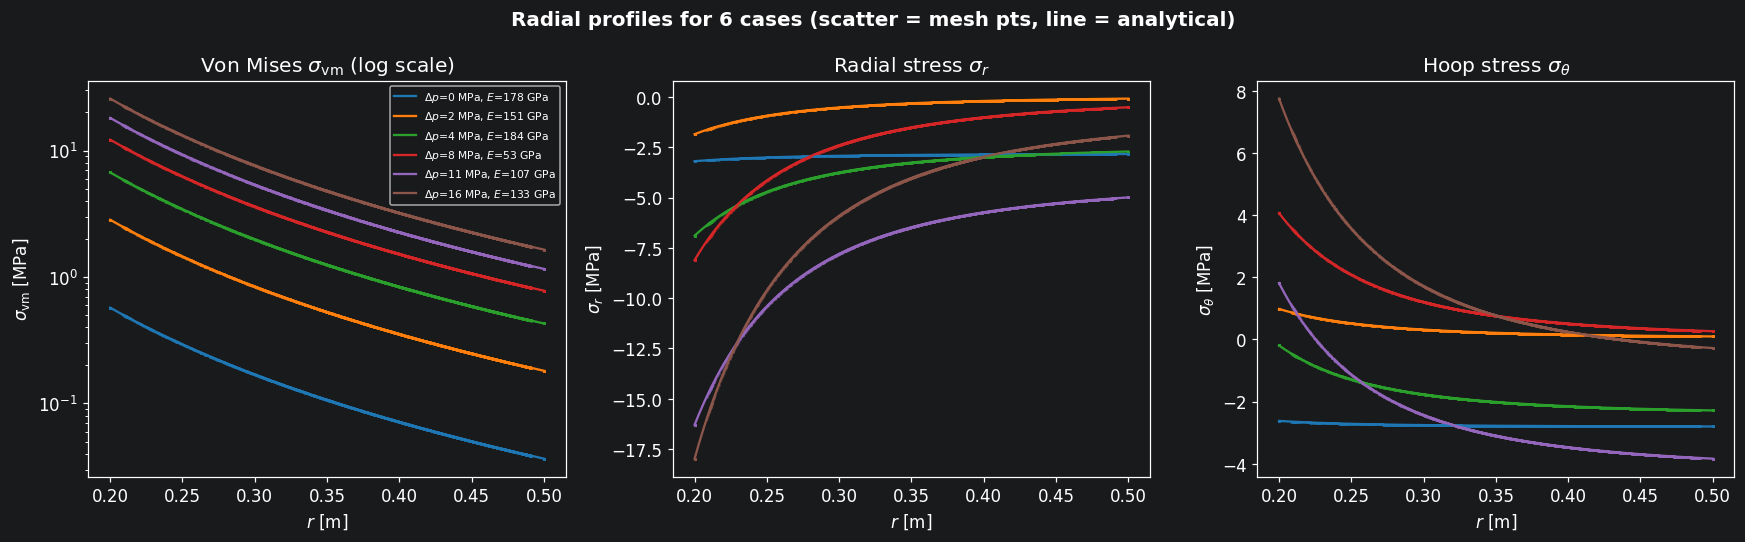

In [10]:
# Pick 6 diverse cases spanning delta_p and E
delta_p_s = params_s[:, 0] - params_s[:, 1]
dp_sorted = np.argsort(delta_p_s)
case_idx = [dp_sorted[i] for i in [5, 35, 65, 95, 140, 185]]

def lame_profiles(p_i, p_e, E, nu, r):
    """Analytical Lamé fields at radii r (array)."""
    A3, B3 = A**3, B**3
    denom = B3 - A3
    C1 = (p_i * A3 - p_e * B3) / denom
    C2 = (p_i - p_e) * A3 * B3 / denom
    r3 = r**3
    svm = np.abs(C2) * 3 / (2 * r3)
    sr  = C1 - C2 / r3
    st  = C1 + C2 / (2 * r3)
    return svm, sr, st

r_line = np.linspace(A, B, 300)
cmap   = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Radial profiles for 6 cases (scatter = mesh pts, line = analytical)",
             fontsize=13, fontweight="bold")

for k, ci in enumerate(case_idx):
    p_i, p_e, E_c, nu_c = params_s[ci]
    color = cmap(k)
    label = f"$\\Delta p$={( p_i-p_e)/1e6:.0f} MPa, $E$={E_c/1e9:.0f} GPa"

    # Analytical curves
    svm_l, sr_l, st_l = lame_profiles(p_i, p_e, E_c, nu_c, r_line)

    for ax, scatter_vals, line_vals, ylabel in [
        (axes[0], sigma_vm_s[ci] / 1e6, svm_l / 1e6, "$\\sigma_\\mathrm{vm}$ [MPa]"),
        (axes[1], sigma_r_s[ci] / 1e6,  sr_l / 1e6,  "$\\sigma_r$ [MPa]"),
        (axes[2], sigma_t_s[ci] / 1e6,  st_l / 1e6,  "$\\sigma_\\theta$ [MPa]"),
    ]:
        ax.scatter(query_r, scatter_vals, s=1, alpha=0.25, color=color)
        ax.plot(r_line, line_vals, color=color, lw=1.5,
                label=label if ax is axes[0] else None)
        ax.set(xlabel="$r$ [m]", ylabel=ylabel)

axes[0].set_title("Von Mises $\\sigma_\\mathrm{vm}$ (log scale)")
axes[0].set_yscale("log")
axes[1].set_title("Radial stress $\\sigma_r$")
axes[2].set_title("Hoop stress $\\sigma_\\theta$")
axes[0].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

## 9 — Parameter → field correlations

delta_p → max(sigma_vm):  slope=1.603 MPa/MPa, R²=1.000
log(E) → log(max(u_r)):   slope=-1.082 (expect ≈ -1),  R²=0.303


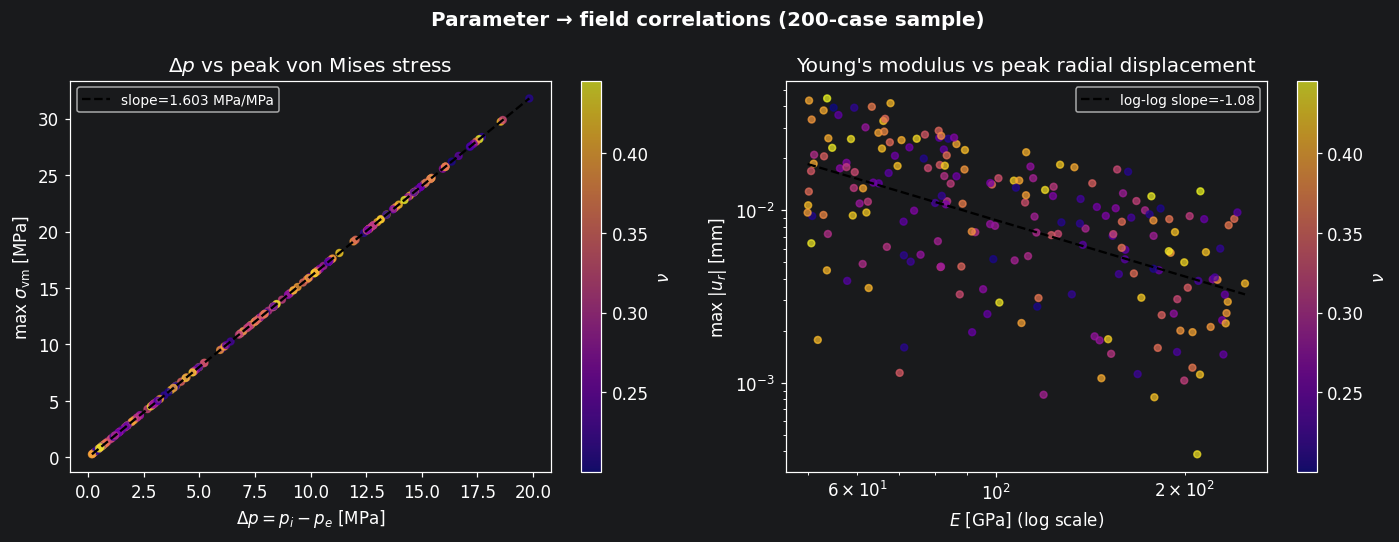

In [11]:
max_svm = sigma_vm_s.max(axis=1) / 1e6   # MPa
max_ur  = np.abs(u_r_s).max(axis=1) * 1e3  # mm
dp_mpa  = (params_s[:, 0] - params_s[:, 1]) / 1e6
E_gpa   = params_s[:, 2] / 1e9
nu_arr  = params_s[:, 3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Parameter → field correlations (200-case sample)",
             fontsize=13, fontweight="bold")

# delta_p vs max(sigma_vm)
sc0 = axes[0].scatter(dp_mpa, max_svm, c=nu_arr, cmap="plasma", s=20, alpha=0.7)
plt.colorbar(sc0, ax=axes[0], label="$\\nu$")
slope0, intercept0 = np.polyfit(dp_mpa, max_svm, 1)
x_fit = np.linspace(dp_mpa.min(), dp_mpa.max(), 100)
axes[0].plot(x_fit, slope0 * x_fit + intercept0, "k--", lw=1.5,
             label=f"slope={slope0:.3f} MPa/MPa")
axes[0].set(xlabel="$\\Delta p = p_i - p_e$ [MPa]",
            ylabel="max $\\sigma_\\mathrm{vm}$ [MPa]",
            title="$\\Delta p$ vs peak von Mises stress")
axes[0].legend(fontsize=9)
print(f"delta_p → max(sigma_vm):  slope={slope0:.3f} MPa/MPa, R²={np.corrcoef(dp_mpa, max_svm)[0,1]**2:.3f}")

# E vs max(u_r)
sc1 = axes[1].scatter(E_gpa, max_ur, c=nu_arr, cmap="plasma", s=20, alpha=0.7)
plt.colorbar(sc1, ax=axes[1], label="$\\nu$")
# fit in log space: log(max_ur) ~ log(1/E)
log_E = np.log(E_gpa)
log_ur = np.log(max_ur)
slope1, intercept1 = np.polyfit(log_E, log_ur, 1)
x_fit_log = np.linspace(log_E.min(), log_E.max(), 100)
axes[1].plot(np.exp(x_fit_log), np.exp(slope1 * x_fit_log + intercept1),
             "k--", lw=1.5, label=f"log-log slope={slope1:.2f}")
axes[1].set(xlabel="$E$ [GPa] (log scale)",
            ylabel="max $|u_r|$ [mm]",
            title="Young's modulus vs peak radial displacement",
            xscale="log", yscale="log")
axes[1].legend(fontsize=9)
print(f"log(E) → log(max(u_r)):   slope={slope1:.3f} (expect ≈ -1),  R²={np.corrcoef(log_E, log_ur)[0,1]**2:.3f}")

plt.tight_layout()
plt.show()

## 10 — Spatial field visualization (cross-section)

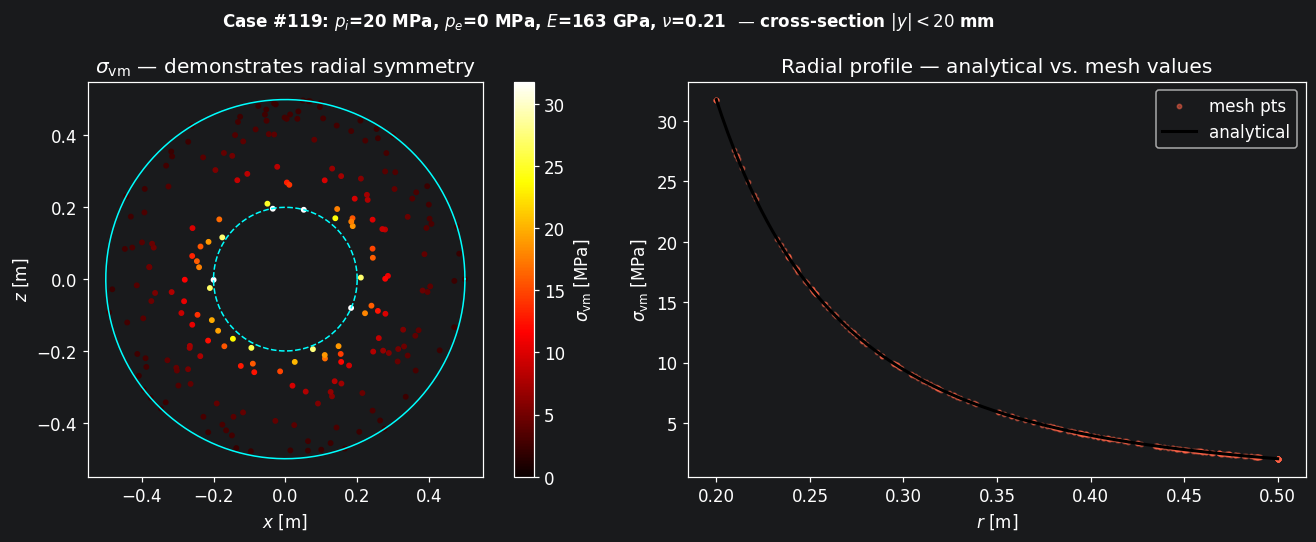

In [12]:
# One representative case: largest delta_p in sample
ci_best = int(np.argmax(params_s[:, 0] - params_s[:, 1]))
p_i_b, p_e_b, E_b, nu_b = params_s[ci_best]

# Use a denser cross-section: all subsampled points near y=0
cs_mask_q = np.abs(QUERY_XYZ[query_idx, 1]) < 0.02
x_q = QUERY_XYZ[query_idx, 0][cs_mask_q]
z_q = QUERY_XYZ[query_idx, 2][cs_mask_q]
svm_q = sigma_vm_s[ci_best][cs_mask_q] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Case #{ci_best}: $p_i$={p_i_b/1e6:.0f} MPa, $p_e$={p_e_b/1e6:.0f} MPa, "
    f"$E$={E_b/1e9:.0f} GPa, $\\nu$={nu_b:.2f}  — cross-section $|y| < 20$ mm",
    fontsize=11, fontweight="bold"
)

# Scatter: sigma_vm
sc = axes[0].scatter(x_q, z_q, c=svm_q, cmap="hot", s=8, vmin=0)
plt.colorbar(sc, ax=axes[0], label="$\\sigma_\\mathrm{vm}$ [MPa]")
for rad, ls in [(A, "--"), (B, "-")]:
    theta = np.linspace(0, 2 * np.pi, 300)
    axes[0].plot(rad * np.cos(theta), rad * np.sin(theta), "cyan", lw=1, ls=ls)
axes[0].set(xlabel="$x$ [m]", ylabel="$z$ [m]", aspect="equal",
            title="$\\sigma_\\mathrm{vm}$ — demonstrates radial symmetry")

# Radial profile comparison: scatter vs analytical
r_q_cs = np.linalg.norm(QUERY_XYZ[query_idx][cs_mask_q], axis=1)
svm_exact, _, _ = lame_profiles(p_i_b, p_e_b, E_b, nu_b, r_line)
axes[1].scatter(r_q_cs, svm_q, s=8, alpha=0.5, color="tomato", label="mesh pts")
axes[1].plot(r_line, svm_exact / 1e6, "k-", lw=2, label="analytical")
axes[1].set(xlabel="$r$ [m]", ylabel="$\\sigma_\\mathrm{vm}$ [MPa]",
            title="Radial profile — analytical vs. mesh values")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11 — Train / val / test distribution comparison

p_i   KS statistic=0.0290  p=0.6676  OK (no shift)
p_e   KS statistic=0.0250  p=0.8273  OK (no shift)
E     KS statistic=0.0508  p=0.0802  OK (no shift)
nu    KS statistic=0.0459  p=0.1436  OK (no shift)


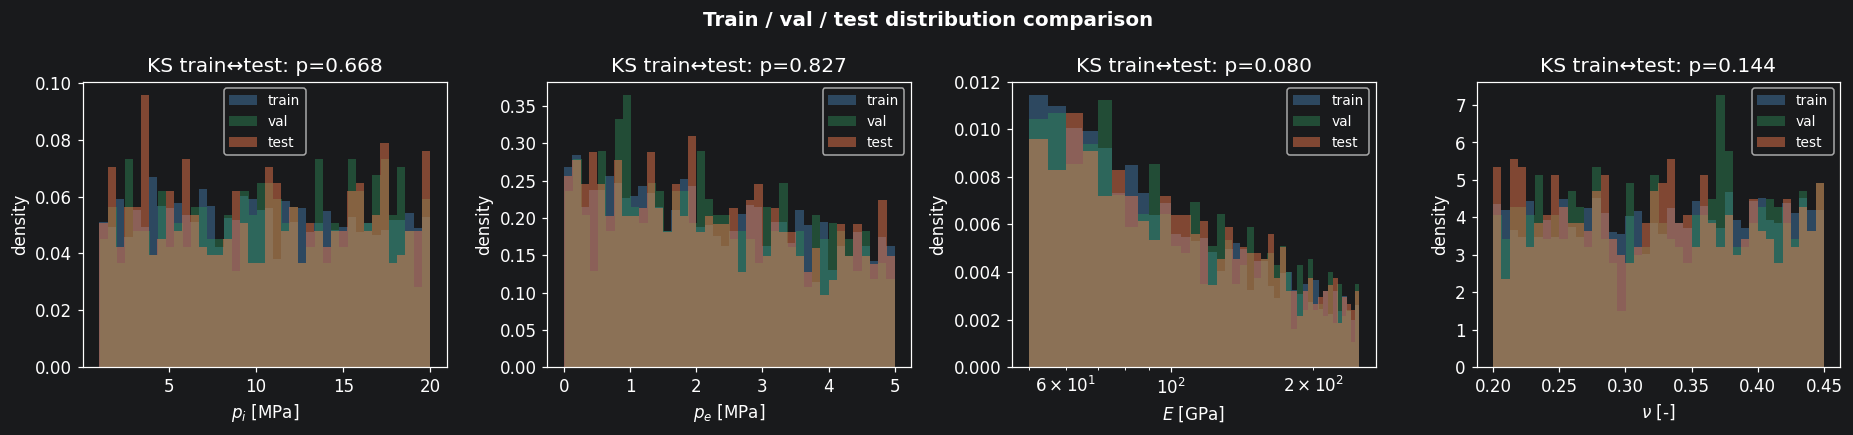

In [13]:
params_to_check = [
    ("p_i",  1e6,  "$p_i$ [MPa]"),
    ("p_e",  1e6,  "$p_e$ [MPa]"),
    ("E",    1e9,  "$E$ [GPa]"),
    ("nu",   1.0,  "$\\nu$ [-]"),
]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle("Train / val / test distribution comparison", fontsize=13, fontweight="bold")

colors = {"train": "steelblue", "val": "seagreen", "test": "coral"}

for ax, (col, scale, xlabel) in zip(axes, params_to_check):
    for split, df in splits.items():
        ax.hist(df[col] / scale, bins=40, alpha=0.45, color=colors[split],
                label=split, density=True, edgecolor="none")

    # KS test: train vs test
    ks_stat, ks_p = stats.ks_2samp(
        splits["train"][col].to_numpy(),
        splits["test"][col].to_numpy()
    )
    ax.set(xlabel=xlabel, ylabel="density",
           title=f"KS train↔test: p={ks_p:.3f}")
    if col == "E":
        ax.set_xscale("log")
    ax.legend(fontsize=9)
    print(f"{col:4s}  KS statistic={ks_stat:.4f}  p={ks_p:.4f}  "
          f"{'OK (no shift)' if ks_p > 0.05 else 'WARN: possible shift'}")

plt.tight_layout()
plt.show()